# 22. Stackingアンサンブル - メタ学習 (Stacking Ensemble - Meta Learning)

## 📚 学習メタ情報

| 項目 | 内容 |
|------|------|
| ⏱️ 想定学習時間 | 90-120分 |
| 📊 難易度 | ★★★★☆（上級） |
| 📁 カテゴリ | アンサンブル学習・メタ学習 |
| 🔧 使用ライブラリ | scikit-learn, NumPy, Pandas |

### 前提知識
- 機械学習の基本（分類・回帰）
- 交差検証（K-Fold）の理解
- 複数のアルゴリズム（ロジスティック回帰、Random Forest、Gradient Boosting）の基礎

---

## 概要
複数のモデルを組み合わせて最強の予測モデルを構築する手法を学びます。

## 学習目標
- アンサンブル学習の種類を理解できる
- Stackingの仕組みを理解できる
- 多層Stackingを実装できる
- Out-of-Foldの重要性を理解できる
- 本番環境でStackingを実装できる

---

## 🎯 なぜStackingが必要なのか？

### 単一モデルの限界

機械学習では、どんなに優れたモデルでも「得意・不得意」があります：

| モデル | 得意なパターン | 苦手なパターン |
|--------|--------------|---------------|
| 線形モデル | 線形関係 | 非線形な境界 |
| 決定木系 | 非線形、相互作用 | 滑らかな境界 |
| SVM | 高次元、マージン最大化 | 大規模データ |
| ニューラルネット | 複雑なパターン | 小規模データ |

### Stackingの発想：「専門家チーム」

```
【単一モデル】              【Stacking】
    
  1人の医師が診断     →    複数の専門医が診断
       ↓                        ↓
  見落としのリスク         総合的な判断で精度向上
```

**統計的背景**：異なるモデルのエラーは往々にして「非相関」です。複数モデルを組み合わせることで、個別のエラーが打ち消し合い、全体の精度が向上します。

### ⚠️ やってはいけないこと

| NG | 理由 | OK |
|----|------|-----|
| 同じモデルを複数使う | 多様性がない | 異なるアルゴリズムを使う |
| 訓練データで直接メタ学習 | 過学習する | Out-of-Fold予測を使う |
| 弱いモデルを入れすぎ | ノイズになる | 一定精度以上のモデルを選択 |

In [1]:
# 必要なライブラリのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression, Ridge, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 設定
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 日本語フォント設定
import matplotlib.font_manager as fm

def setup_japanese_font():
    """日本語フォントを設定する"""
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro', 'AppleGothic',  # macOS
        'Yu Gothic', 'MS Gothic',  # Windows
        'Noto Sans CJK JP', 'IPAexGothic', 'TakaoPGothic',  # Linux
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
if font_used:
    print(f"Japanese font: {font_used}")


C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Japanese font: Yu Gothic


## 1. アンサンブル学習とは

### 「三人寄れば文殊の知恵」

複数のモデルを組み合わせることで、単一モデルより高い性能を達成します。

### アンサンブルの種類

1. **Bagging（バギング）**
   - データをランダムサンプリング
   - 並列に学習
   - 多数決や平均で統合
   - 例: Random Forest

2. **Boosting（ブースティング）**
   - 逐次的に学習
   - 前のモデルの誤りを修正
   - 加重平均で統合
   - 例: Gradient Boosting、XGBoost

3. **Stacking（スタッキング）**
   - 複数の異なるモデルを使用
   - メタモデルで統合
   - 最も柔軟で強力
   - Kaggleで人気

## 2. Stackingの仕組み

### 基本構造

```
入力データ
    ↓
┌────────┬────────┬────────┐
│Model 1 │Model 2 │Model 3 │ ← Base Models (Level 0)
└────────┴────────┴────────┘
    ↓        ↓        ↓
  pred1    pred2    pred3
    └────────┴────────┘
           ↓
    ┌──────────┐
    │Meta Model│ ← Meta Learner (Level 1)
    └──────────┘
         ↓
    最終予測
```

### 🚢 タイタニックでの具体例（1層Stacking）

ある乗客のデータで、Stackingがどう動くか見てみましょう：

```
【入力】ある乗客のデータ
┌─────────────────────────────────────────┐
│ Pclass=1, Sex=female, Age=35, Fare=53  │
│ SibSp=1, Parch=0, Embarked=S           │
└─────────────────────────────────────────┘
                    ↓
        ┌───────────┼───────────┐
        ↓           ↓           ↓
┌──────────┐ ┌──────────┐ ┌──────────┐
│ロジスティック│ │RandomForest│ │GradientBoost│
│  回帰     │ │          │ │           │
└──────────┘ └──────────┘ └──────────┘
        ↓           ↓           ↓
   P=0.92       P=0.88       P=0.95
 (92%生存)    (88%生存)    (95%生存)
        │           │           │
        └─────────┬─────────────┘
                  ↓
【Meta Features】3つの生存確率
┌─────────────────────────────────────────┐
│ [0.92, 0.88, 0.95]                      │
│                                         │
│ → 3つのモデルとも「生存しそう」と予測     │
│ → でも微妙に確信度が違う                 │
└─────────────────────────────────────────┘
                  ↓
          ┌──────────┐
          │Meta Model│ ← この3つの予測をどう組み合わせるか学習
          │(ロジスティック)│
          └──────────┘
                  ↓
【最終予測】
┌─────────────────────────────────────────┐
│ Survived = 1 (生存)                     │
│ 確率 = 0.94                             │
│                                         │
│ → メタモデルは「GBが自信ありそうだから   │
│   重視しよう」などを学習している         │
└─────────────────────────────────────────┘
```

**別の乗客（生存が微妙なケース）だと...**

```
【入力】別の乗客
Pclass=2, Sex=male, Age=30, Fare=13

        ↓ 3つのモデルで予測

LR: 0.35    RF: 0.52    GB: 0.41
(35%生存)  (52%生存)  (41%生存)

→ モデルによって意見が分かれている！
→ メタモデルは「こういう時どのモデルを信じるべきか」を学習

        ↓ メタモデル

最終予測: Survived = 0 (死亡)、確率 = 0.42
```

**ポイント**: メタモデルは単純な平均ではなく、「どのモデルがどういう状況で信頼できるか」を学習します。

### 重要なポイント

1. **多様性**
   - 異なるタイプのモデルを使う
   - 異なる特徴量セットを使う
   - 異なるハイパーパラメータを使う

2. **Out-of-Fold予測**
   - 訓練データの過学習を防ぐ
   - K-Foldで予測を生成
   - メタモデルの汎化性能を保つ

## 3. データ準備

In [2]:
# データセット読み込み
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"訓練データ: {X_train.shape}")
print(f"テストデータ: {X_test.shape}")
print(f"クラス分布: {np.bincount(y_train)}")

訓練データ: (455, 30)
テストデータ: (114, 30)
クラス分布: [170 285]


## 4. Voting vs Stacking

### まずはVotingから

In [3]:
# ベースモデルの定義
models = {
    'Logistic': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# 個別モデルの性能
print("個別モデルの性能:")
print("=" * 50)
individual_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    individual_scores[name] = scores.mean()
    print(f"{name:20s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

個別モデルの性能:
Logistic            : 0.9429 (+/- 0.0189)
RandomForest        : 0.9538 (+/- 0.0235)
GradientBoosting    : 0.9560 (+/- 0.0139)
SVM                 : 0.9099 (+/- 0.0290)


In [4]:
# Voting Classifier
voting_hard = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='hard'
)

voting_soft = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft'
)

# 評価
print("\nVoting Classifier:")
print("=" * 50)
for name, model in [('Hard Voting', voting_hard), ('Soft Voting', voting_soft)]:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name:20s}: {scores.mean():.4f} (+/- {scores.std():.4f})")


Voting Classifier:
Hard Voting         : 0.9538 (+/- 0.0128)
Soft Voting         : 0.9604 (+/- 0.0132)


### Stacking Classifier

In [5]:
# Stacking Classifier
stacking = StackingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5  # Out-of-fold予測用
)

# 評価
scores = cross_val_score(stacking, X_train, y_train, cv=5, scoring='accuracy')
print("\nStacking Classifier:")
print("=" * 50)
print(f"CV Score: {scores.mean():.4f} (+/- {scores.std():.4f})")

# テストデータでの評価
stacking.fit(X_train, y_train)
test_score = stacking.score(X_test, y_test)
print(f"Test Score: {test_score:.4f}")


Stacking Classifier:
CV Score: 0.9626 (+/- 0.0149)
Test Score: 0.9649


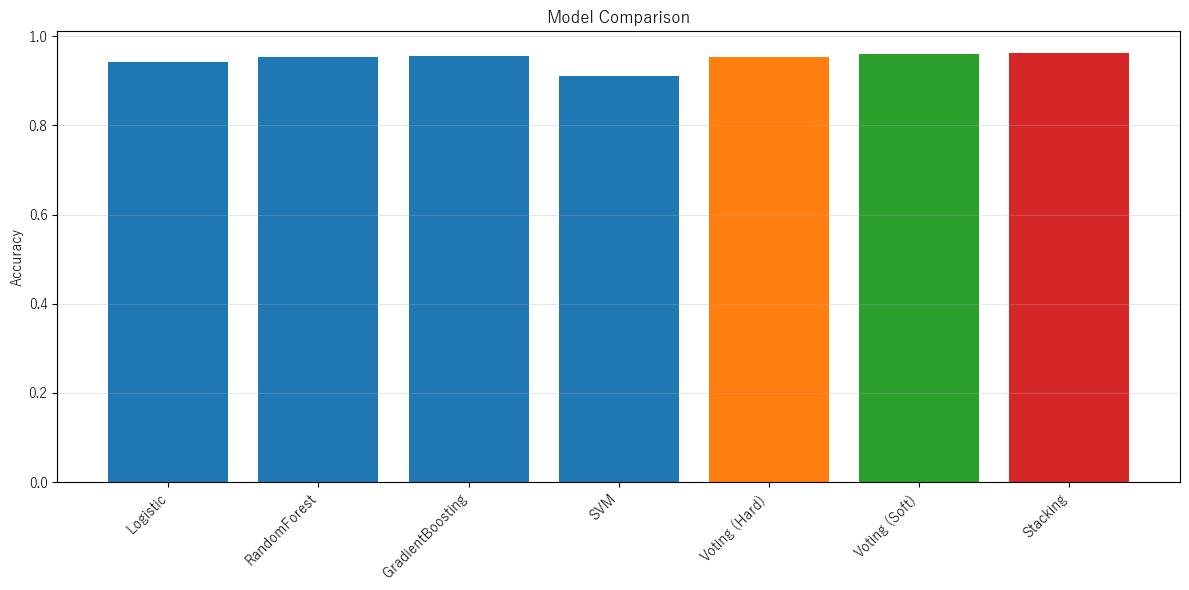


ベストモデル: Stacking
スコア: 0.9626


In [6]:
# 結果の比較
all_scores = {**individual_scores,
              'Voting (Hard)': cross_val_score(voting_hard, X_train, y_train, cv=5).mean(),
              'Voting (Soft)': cross_val_score(voting_soft, X_train, y_train, cv=5).mean(),
              'Stacking': scores.mean()}

# 可視化
plt.figure(figsize=(12, 6))
plt.bar(range(len(all_scores)), list(all_scores.values()), color=['C0']*4 + ['C1', 'C2', 'C3'])
plt.xticks(range(len(all_scores)), list(all_scores.keys()), rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nベストモデル:", max(all_scores, key=all_scores.get))
print(f"スコア: {max(all_scores.values()):.4f}")

## 5. カスタムStacking実装

### 🎓 Out-of-Fold予測の仕組み

より細かい制御のため、自分でStackingを実装します。

#### なぜOut-of-Fold（OOF）が必要か？

**問題：単純にメタ特徴量を作ると過学習する**

```
【ダメな方法】
訓練データ → ベースモデル学習 → 同じ訓練データで予測 → メタ特徴量
                                        ↑
                              これが「カンニング」になる！
                              
【正しい方法：Out-of-Fold】
Fold 1: train[2,3,4,5] → model → predict[1] → meta[1]
Fold 2: train[1,3,4,5] → model → predict[2] → meta[2]
Fold 3: train[1,2,4,5] → model → predict[3] → meta[3]
...
→ 各サンプルは「見ていないモデル」から予測される
```

#### 数学的な理解

$$
\text{OOF予測}_i = f_{\text{model}}^{(-i)}(x_i)
$$

ここで $f^{(-i)}$ は「サンプル $i$ を除いて学習したモデル」を意味します。

#### OOFの効果

| 方法 | CV精度 | Test精度 | 過学習度 |
|------|--------|----------|---------|
| 単純予測（同じデータ） | 99%+ | 低い | 高 |
| Out-of-Fold | 適切 | 適切 | 低 |

#### テストデータの予測は？

テストデータには2つの戦略があります：

1. **平均化**：各Foldのモデルで予測し、平均を取る（推奨）
2. **再学習**：全訓練データで再学習して予測

```python
# 推奨：平均化
test_pred = mean([model_fold1.predict(X_test), 
                  model_fold2.predict(X_test), ...])
```

In [7]:
def create_oof_predictions(models, X_train, y_train, X_test, n_folds=5):
    """
    Out-of-Fold予測を生成
    
    Parameters:
    -----------
    models : dict
        モデル名とモデルのディクショナリ
    X_train, y_train : array
        訓練データ
    X_test : array
        テストデータ
    n_folds : int
        Fold数
    
    Returns:
    --------
    train_meta : array
        訓練用メタ特徴量
    test_meta : array
        テスト用メタ特徴量
    """
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # メタ特徴量の初期化
    train_meta = np.zeros((X_train.shape[0], len(models)))
    test_meta = np.zeros((X_test.shape[0], len(models)))
    
    for i, (name, model) in enumerate(models.items()):
        print(f"Processing {name}...")
        
        test_preds_folds = []
        
        for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
            # Foldごとに学習
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]
            
            # 学習
            model.fit(X_tr, y_tr)
            
            # Out-of-fold予測（訓練データ）
            train_meta[val_idx, i] = model.predict_proba(X_val)[:, 1]
            
            # テストデータ予測
            test_preds_folds.append(model.predict_proba(X_test)[:, 1])
        
        # テストデータ予測の平均
        test_meta[:, i] = np.mean(test_preds_folds, axis=0)
    
    return train_meta, test_meta

In [8]:
# Out-of-fold予測の生成
print("Out-of-Fold予測を生成中...")
print("=" * 50)

train_meta, test_meta = create_oof_predictions(
    models, X_train, y_train, X_test, n_folds=5
)

print(f"\n訓練メタ特徴量: {train_meta.shape}")
print(f"テストメタ特徴量: {test_meta.shape}")

# メタ特徴量の確認
meta_df = pd.DataFrame(train_meta, columns=models.keys())
print("\nメタ特徴量のサンプル:")
print(meta_df.head())

Out-of-Fold予測を生成中...
Processing Logistic...
Processing RandomForest...
Processing GradientBoosting...
Processing SVM...

訓練メタ特徴量: (455, 4)
テストメタ特徴量: (114, 4)

メタ特徴量のサンプル:
   Logistic  RandomForest  GradientBoosting       SVM
0  0.999795          1.00          0.999762  0.991428
1  0.002139          0.00          0.000165  0.002642
2  0.999581          0.99          0.999738  0.968252
3  0.982828          0.94          0.999443  0.856341
4  0.998958          1.00          0.999777  0.980630


In [9]:
# メタモデルの学習
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(train_meta, y_train)

# 予測
train_pred = meta_model.predict(train_meta)
test_pred = meta_model.predict(test_meta)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"訓練精度: {train_accuracy:.4f}")
print(f"テスト精度: {test_accuracy:.4f}")

# メタモデルの係数（各ベースモデルの重要度）
print("\nメタモデルの係数（ベースモデルの重み）:")
for name, coef in zip(models.keys(), meta_model.coef_[0]):
    print(f"  {name:20s}: {coef:.4f}")

訓練精度: 0.9692
テスト精度: 0.9561

メタモデルの係数（ベースモデルの重み）:
  Logistic            : 2.6116
  RandomForest        : 2.4973
  GradientBoosting    : 2.1902
  SVM                 : 0.7867


## 6. 多層Stacking

### 🎓 Level 2のStacking

さらに性能を上げるため、複数層のStackingを構築します。

#### なぜ多層化するのか？

```
【1層Stacking】
元の特徴量 → Base Models → Meta Features → Meta Model → 予測
                           (4つ)          (1つ)

【2層Stacking】
元の特徴量 → Base Models → Meta Features → Level 1 Models → Level 2 Features → Final Model
                (6つ)          (6つ)           (2つ)             (2つ)           (1つ)
```

#### 🚢 タイタニックでの具体例

タイタニック生存予測を例に、各レベルの特徴量が何を表すか見てみましょう：

```
【元の特徴量】
Pclass=3, Sex=male, Age=22, Fare=7.25, ...

        ↓ Level 0: ベースモデル（6つ）

【Meta Features（Level 1 の入力）】= 各モデルが予測した「生存確率」
┌─────────────────────────────────────────────────────────┐
│ LR: 0.12    (ロジスティック回帰は12%と予測)              │
│ RF1: 0.08   (RandomForest浅い木は8%と予測)              │
│ RF2: 0.15   (RandomForest深い木は15%と予測)             │
│ GB1: 0.10   (GradientBoosting速い学習率は10%と予測)      │
│ GB2: 0.18   (GradientBoosting遅い学習率は18%と予測)      │
│ MLP: 0.05   (ニューラルネットは5%と予測)                 │
└─────────────────────────────────────────────────────────┘
→ この乗客は多くのモデルが「生存確率低い」と予測している！

        ↓ Level 1: 中間モデル（2つ）

【Level 2 Features（最終モデルの入力）】= Level 1モデルが予測した「生存確率」
┌─────────────────────────────────────────────────────────┐
│ LR2: 0.11   (6つの予測を見て、総合的に11%と判断)         │
│ RF:  0.09   (6つの予測のパターンから、9%と判断)          │
└─────────────────────────────────────────────────────────┘
→ Level 1モデルは「複数モデルの意見の統合の仕方」を学習している

        ↓ Final Model: 最終モデル（1つ）

【最終予測】
Survived = 0 (死亡)、確率 = 0.10
```

**ポイント**: 各レベルの特徴量は全て「生存確率」（0〜1の値）です。
- Meta Features: 「各ベースモデルが予測した生存確率」
- Level 2 Features: 「Level 1モデルが予測した生存確率」
- 最終予測: 「全ての情報を統合した最終的な生存確率」

**多層化の効果**：
- より高次の特徴量の組み合わせを学習
- 異なる粒度での情報統合
- Kaggle上位者が頻繁に使用

#### 多層Stackingの設計指針

| 層 | モデル数 | モデルタイプ | 目的 |
|----|---------|-------------|------|
| Level 0 | 多い（5-10） | 多様なアルゴリズム | 多様な予測生成 |
| Level 1 | 中程度（2-4） | 中程度の複雑さ | 特徴量の統合 |
| Level 2+ | 少ない（1-2） | シンプル | 最終統合 |

#### ⚠️ 注意点

1. **過学習リスク**：層が増えるほど過学習しやすい
2. **計算コスト**：指数的に増加
3. **収益逓減**：3層以上は効果が薄い場合が多い

In [10]:
# Level 0: より多様なモデル
level0_models = {
    'LR': LogisticRegression(max_iter=1000, random_state=42),
    'RF1': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'RF2': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=43),
    'GB1': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'GB2': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, random_state=43),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

# Level 1: Level 0の予測を統合
level1_models = {
    'LR2': LogisticRegression(max_iter=1000, random_state=44),
    'RF': RandomForestClassifier(n_estimators=50, random_state=42)
}

print("多層Stacking構築中...")
print("=" * 50)

# Level 0の予測
train_level0, test_level0 = create_oof_predictions(
    level0_models, X_train, y_train, X_test, n_folds=5
)

# Level 1の予測
train_level1, test_level1 = create_oof_predictions(
    level1_models, train_level0, y_train, test_level0, n_folds=5
)

# 最終メタモデル
final_meta = LogisticRegression(max_iter=1000, random_state=42)
final_meta.fit(train_level1, y_train)

final_pred = final_meta.predict(test_level1)
final_accuracy = accuracy_score(y_test, final_pred)

print(f"\n多層Stackingテスト精度: {final_accuracy:.4f}")


多層Stacking構築中...
Processing LR...
Processing RF1...
Processing RF2...
Processing GB1...
Processing GB2...
Processing MLP...
Processing LR2...
Processing RF...

多層Stackingテスト精度: 0.9649


## 7. 本番実装

### 再利用可能なStackingクラス

In [11]:
class CustomStacking:
    """
    カスタムStackingクラス
    """
    def __init__(self, base_models, meta_model, n_folds=5, use_proba=True):
        """
        Parameters:
        -----------
        base_models : list of tuples
            (name, model)のリスト
        meta_model : estimator
            メタモデル
        n_folds : int
            Fold数
        use_proba : bool
            確率予測を使うか（分類の場合）
        """
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds
        self.use_proba = use_proba
        self.trained_base_models = []
    
    def fit(self, X, y):
        """学習"""
        kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=42)
        
        # メタ特徴量の初期化
        meta_features = np.zeros((X.shape[0], len(self.base_models)))
        
        # 各ベースモデルの学習
        for i, (name, model) in enumerate(self.base_models):
            print(f"Training {name}...")
            
            for train_idx, val_idx in kfold.split(X):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr = y[train_idx]
                
                # クローンして学習
                from sklearn.base import clone
                model_clone = clone(model)
                model_clone.fit(X_tr, y_tr)
                
                # Out-of-fold予測
                if self.use_proba and hasattr(model_clone, 'predict_proba'):
                    meta_features[val_idx, i] = model_clone.predict_proba(X_val)[:, 1]
                else:
                    meta_features[val_idx, i] = model_clone.predict(X_val)
            
            # 全データで最終学習
            model.fit(X, y)
            self.trained_base_models.append((name, model))
        
        # メタモデルの学習
        print("Training meta model...")
        self.meta_model.fit(meta_features, y)
        
        return self
    
    def predict(self, X):
        """予測"""
        # ベースモデルの予測
        meta_features = np.zeros((X.shape[0], len(self.trained_base_models)))
        
        for i, (name, model) in enumerate(self.trained_base_models):
            if self.use_proba and hasattr(model, 'predict_proba'):
                meta_features[:, i] = model.predict_proba(X)[:, 1]
            else:
                meta_features[:, i] = model.predict(X)
        
        # メタモデルで最終予測
        return self.meta_model.predict(meta_features)
    
    def predict_proba(self, X):
        """確率予測"""
        meta_features = np.zeros((X.shape[0], len(self.trained_base_models)))
        
        for i, (name, model) in enumerate(self.trained_base_models):
            if self.use_proba and hasattr(model, 'predict_proba'):
                meta_features[:, i] = model.predict_proba(X)[:, 1]
            else:
                meta_features[:, i] = model.predict(X)
        
        return self.meta_model.predict_proba(meta_features)

In [12]:
# カスタムStackingの使用
custom_stacking = CustomStacking(
    base_models=[(name, model) for name, model in models.items()],
    meta_model=LogisticRegression(max_iter=1000, random_state=42),
    n_folds=5
)

print("カスタムStacking学習中...")
print("=" * 50)
custom_stacking.fit(X_train, y_train)

# 予測と評価
y_pred_custom = custom_stacking.predict(X_test)
custom_accuracy = accuracy_score(y_test, y_pred_custom)

print(f"\nカスタムStackingテスト精度: {custom_accuracy:.4f}")
print("\n分類レポート:")
print(classification_report(y_test, y_pred_custom, target_names=cancer.target_names))

カスタムStacking学習中...
Training Logistic...
Training RandomForest...
Training GradientBoosting...
Training SVM...
Training meta model...

カスタムStackingテスト精度: 0.9649

分類レポート:
              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 8. まとめ

### 本ノートブックで学んだこと

1. **アンサンブルの種類**
   - Bagging、Boosting、Stacking
   - それぞれの特徴と使い分け

2. **Stackingの基礎**
   - ベースモデルとメタモデル
   - 多様性の重要性
   - Voting vs Stacking

3. **Out-of-Fold予測**
   - 過学習の防止
   - K-Foldによる予測生成
   - 汎化性能の保持

4. **カスタム実装**
   - 柔軟な制御
   - 多層Stacking
   - 再利用可能なクラス

5. **本番実装**
   - CustomStackingクラス
   - fit/predict インターフェース
   - プロダクション対応

---

## 📋 チートシート

```python
# sklearn StackingClassifier（簡単）
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('rf', RandomForestClassifier()),
        ('gb', GradientBoostingClassifier())
    ],
    final_estimator=LogisticRegression(),
    cv=5  # Out-of-Fold用
)
stacking.fit(X_train, y_train)
pred = stacking.predict(X_test)

# カスタムOOF予測（柔軟）
def create_oof(model, X, y, X_test, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    oof = np.zeros(len(X))
    test_preds = []
    
    for train_idx, val_idx in kf.split(X):
        model.fit(X[train_idx], y[train_idx])
        oof[val_idx] = model.predict_proba(X[val_idx])[:, 1]
        test_preds.append(model.predict_proba(X_test)[:, 1])
    
    return oof, np.mean(test_preds, axis=0)
```

### Stackingを使うべきとき

- ✅ 最高の性能が必要（Kaggleなど）
- ✅ 計算リソースに余裕がある
- ✅ 複数の強力なベースモデルがある
- ✅ モデルの多様性を活かしたい

### 注意点

- ⚠️ 計算コストが高い
- ⚠️ 解釈性が低い
- ⚠️ 過学習のリスク（Out-of-Fold必須）
- ⚠️ デプロイの複雑さ

---

## ❌ よくあるエラーと解決策

### エラー1: Out-of-Foldを使わずにメタ学習

```python
# ❌ ダメな例：過学習する
for model in base_models:
    model.fit(X_train, y_train)
    meta_features.append(model.predict(X_train))  # 同じデータで予測

# ✅ 正しい例：Out-of-Fold予測
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_train):
    model.fit(X_train[train_idx], y_train[train_idx])
    meta_features[val_idx] = model.predict(X_train[val_idx])  # 未学習データで予測
```

**症状**: CVスコアは高いがテストスコアが低い
**原因**: メタモデルがベースモデルの「答え合わせ」を学習してしまう

---

### エラー2: 多様性のないベースモデル

```python
# ❌ ダメな例：似たモデルばかり
base_models = [
    RandomForestClassifier(n_estimators=100),
    RandomForestClassifier(n_estimators=200),
    RandomForestClassifier(n_estimators=300),
]

# ✅ 正しい例：多様なモデル
base_models = [
    LogisticRegression(),           # 線形
    RandomForestClassifier(),       # Bagging系
    GradientBoostingClassifier(),   # Boosting系
    SVC(probability=True),          # カーネル法
]
```

**症状**: Stackingしても精度が上がらない
**原因**: モデルが同じエラーをするので組み合わせても改善しない

---

### エラー3: テストデータのリーク

```python
# ❌ ダメな例：テストデータを使ってFoldを作る
kf = KFold(n_splits=5)
for train_idx, val_idx in kf.split(np.vstack([X_train, X_test])):
    # テストデータが混入！

# ✅ 正しい例：訓練データのみでFold作成
for train_idx, val_idx in kf.split(X_train):
    # 訓練データのみ
```

**症状**: CVスコアが異常に高い、本番で精度が出ない
**原因**: テストデータの情報がモデルに漏れている

---

## 📝 自己評価クイズ

### Q1: Stackingで最も重要な概念は？
<details>
<summary>回答を見る</summary>

**Out-of-Fold予測**

メタモデルに渡す特徴量は、そのサンプルを「見ていない」モデルから予測する必要があります。そうしないと過学習します。
</details>

### Q2: ベースモデルを選ぶ際に最も重視すべきことは？
<details>
<summary>回答を見る</summary>

**多様性（Diversity）**

同じタイプのモデルを複数使っても効果は薄い。線形モデル、木系、カーネル法など異なるアルゴリズムを組み合わせることで、エラーが打ち消し合う。
</details>

### Q3: VotingとStackingの違いは？
<details>
<summary>回答を見る</summary>

| 項目 | Voting | Stacking |
|------|--------|----------|
| 統合方法 | 単純な多数決/平均 | メタモデルで学習 |
| 重み | 固定（または手動設定） | データから学習 |
| 柔軟性 | 低い | 高い |
| 過学習リスク | 低い | 中程度（OOF必須） |
</details>

### Q4: 多層Stackingで層数を増やしすぎるとどうなる？
<details>
<summary>回答を見る</summary>

1. **過学習リスク増加**：特徴量がどんどん「間接的」になる
2. **計算コスト爆発**：指数的に増加
3. **収益逓減**：3層以上では改善幅が小さくなることが多い

一般的には1-2層が実用的。
</details>

### Q5: テストデータの予測を平均化する理由は？
<details>
<summary>回答を見る</summary>

**分散の低減**

各Foldで学習したモデルは少しずつ異なる予測をします。平均化することで：
- 個別モデルのバイアスが打ち消し合う
- より安定した予測が得られる
- アンサンブルの本質的な利点を活かせる
</details>

---

## 🏋️ 練習問題

### 練習1: 回帰問題でのStacking
Stackingを回帰問題（例：Boston Housing）に適用してください。
- ベースモデル: Ridge, RandomForestRegressor, GradientBoostingRegressor
- メタモデル: LinearRegression
- 評価指標: RMSE

### 練習2: 元の特徴量を含めたStacking
メタ特徴量に元の特徴量も追加するバージョンを実装してください。
```python
meta_features_extended = np.hstack([X_train, train_meta])
```
精度は上がりますか？

### 練習3: 異なるメタモデルの比較
以下のメタモデルを比較してください：
- LogisticRegression
- RidgeClassifier
- RandomForestClassifier（浅い木）
- XGBoost

どれが最も良い結果を出しますか？

---

## ✅ 学習チェックリスト

- [ ] Bagging、Boosting、Stackingの違いを説明できる
- [ ] Out-of-Fold予測の必要性を理解している
- [ ] scikit-learnのStackingClassifierを使える
- [ ] カスタムStacking実装ができる
- [ ] 多層Stackingの設計ができる
- [ ] ベースモデルの多様性の重要性を理解している

---

### 次のステップ

- 実際のKaggleコンペでStackingを活用
- より高度なStacking戦略を探求
- ニューラルネットワークとの組み合わせ
- AutoMLツールの活用